# Time Plot Gallery

Time plots aggregate transactional data into period buckets (daily, weekly, monthly) and trace the result as a line, making them the workhorse for any retail trend question. They show the *shape* of activity over time so the eye can land on direction, level shifts, and seasonality at a glance.

Time plots excel at:
- **Trend tracking**: see whether daily revenue is climbing, plateauing, or rolling over
- **Seasonality**: surface holiday spikes, summer dips, weekday/weekend rhythms
- **Promo impact**: anchor a level shift to the date a campaign or price change went live
- **Category comparisons**: overlay a few categories or stores on the same axis to read relative performance

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openretailscience.plots import time
from openretailscience.plots.styles.graph_utils import set_axis_shorthand

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each dataset reflects a real retail rhythm (weekend uplift, holiday peak,
# campaign-driven level shift) so the chart title is true at a glance.

# 1) Two weeks of daily revenue around Valentine's Day 2024.
# Feb 1 2024 is a Thursday. Weekends carry an uplift; Feb 14 (Wed) spikes
# from gifting demand. No random noise - values are set to tell the story.
fortnight_revenue = pd.DataFrame(
    {
        "transaction_date": pd.date_range("2024-02-01", periods=14, freq="D"),
        "revenue": [
            18_000,  # Thu Feb 1
            22_000,  # Fri Feb 2
            31_000,  # Sat Feb 3
            28_000,  # Sun Feb 4
            16_500,  # Mon Feb 5
            17_200,  # Tue Feb 6
            18_000,  # Wed Feb 7
            19_500,  # Thu Feb 8
            24_000,  # Fri Feb 9
            33_000,  # Sat Feb 10
            30_000,  # Sun Feb 11
            17_500,  # Mon Feb 12
            21_000,  # Tue Feb 13
            38_000,  # Wed Feb 14 (Valentine's Day)
        ],
    },
)

# 2) Full year of daily revenue 2023, with a clear Q4 holiday lift.
# Daily values are constant per month so monthly totals are exact.
_monthly_daily_value = {
    1: 8_000,  # Jan: post-holiday slowdown
    2: 7_500,  # Feb
    3: 8_000,  # Mar
    4: 9_000,  # Apr
    5: 9_500,  # May
    6: 10_000,  # Jun
    7: 10_000,  # Jul
    8: 9_500,  # Aug
    9: 9_000,  # Sep
    10: 11_000,  # Oct
    11: 16_000,  # Nov: Black Friday lift
    12: 26_000,  # Dec: holiday peak
}
_year_dates = pd.date_range("2023-01-01", "2023-12-31", freq="D")
annual_sales = pd.DataFrame(
    {
        "transaction_date": _year_dates,
        "sales": [_monthly_daily_value[d.month] for d in _year_dates],
    },
)

# 3) Per-transaction order values across 12 weeks (Apr 22 - Jul 14 2024).
# A loyalty promo launches on Mon Jun 3 (start of week 7), lifting AOV from
# $65 to $83. Five orders per day, all at the period's AOV - so weekly mean
# is exactly $65 before launch and exactly $83 after.
_promo_launch = pd.Timestamp("2024-06-03")
_quarter_dates = pd.date_range("2024-04-22", "2024-07-14", freq="D")
_orders_per_day = 5
_repeated_dates = _quarter_dates.repeat(_orders_per_day)
transactions = pd.DataFrame(
    {
        "transaction_date": _repeated_dates,
        "order_value": np.where(_repeated_dates >= _promo_launch, 83.0, 65.0),
    },
)

# 4) Twelve weeks of daily category revenue. Electronics holds roughly flat
# around $77K/wk, Apparel ramps from ~$35K/wk to ~$89K/wk, Home softens from
# ~$49K/wk to ~$26K/wk. Seeded daily noise breaks the otherwise perfectly
# linear weekly aggregates so the lines read like real retail data.
_category_weeks = 12
_category_dates = pd.date_range("2024-01-01", periods=_category_weeks * 7, freq="D")
_week_index = np.repeat(np.arange(_category_weeks), 7)
_electronics_baseline = np.full(len(_category_dates), 11_000.0)
_apparel_baseline = 5_000.0 + 700.0 * _week_index
_home_baseline = 7_000.0 - 300.0 * _week_index
_category_rng = np.random.default_rng(19)
_DAILY_CATEGORY_NOISE = 0.05
category_sales = pd.concat(
    [
        pd.DataFrame(
            {
                "transaction_date": _category_dates,
                "category": cat,
                "revenue": (
                    baseline * (1 + _category_rng.normal(0, _DAILY_CATEGORY_NOISE, size=len(_category_dates)))
                ).round(0),
            },
        )
        for cat, baseline in [
            ("Electronics", _electronics_baseline),
            ("Apparel", _apparel_baseline),
            ("Home & Garden", _home_baseline),
        ]
    ],
    ignore_index=True,
)

## Basic Time Series

The simplest call: pass the value column and the function aggregates it by day. Reach for this when the question is *what does the recent rhythm look like*: weekend lifts, weekday baselines, and one-off spikes all read at a glance.

---

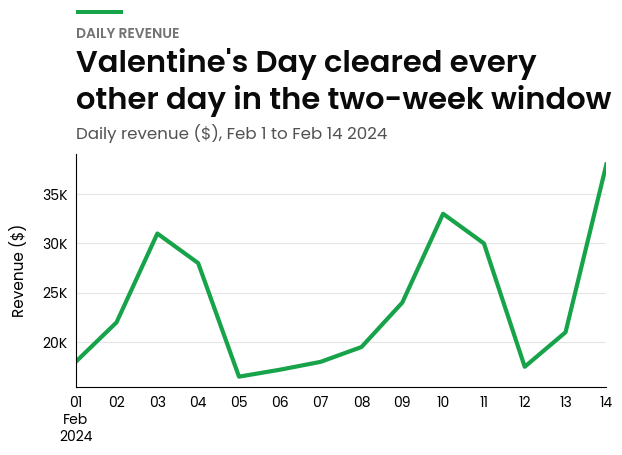

In [ ]:
ax = time.plot(
    fortnight_revenue,
    value_col="revenue",
    eyebrow="Daily revenue",
    title="Valentine's Day cleared every other day in the two-week window",
    subtitle="Daily revenue ($), Feb 1 to Feb 14 2024",
    y_label="Revenue ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Different Time Periods

Use `period` to roll the daily data up into wider buckets: `"D"` (default), `"W"`, or `"M"`. Pick the period that matches the time horizon of the question: daily for a two-week diagnostic, monthly for an annual review. Aggregating up smooths out weekday noise so seasonality reads cleanly.

---

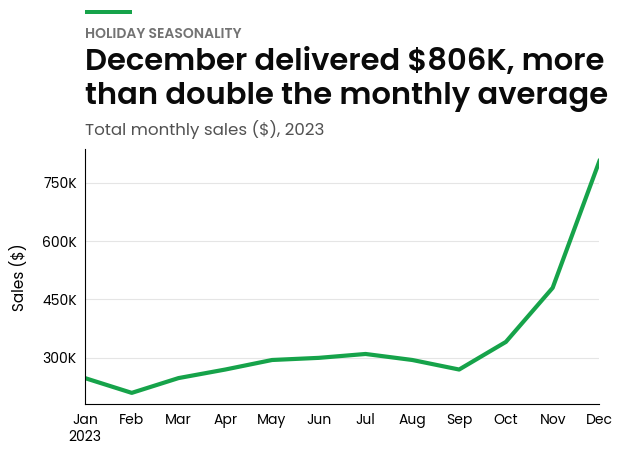

In [ ]:
ax = time.plot(
    annual_sales,
    value_col="sales",
    period="M",
    eyebrow="Holiday seasonality",
    title="December delivered $806K, more than double the monthly average",
    subtitle="Total monthly sales ($), 2023",
    y_label="Sales ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Different Aggregation Functions

`agg_func` controls what the bucket value means: `"sum"` (default) totals up the period, `"mean"` gives the per-row average. Use `"mean"` when the row count varies between periods and you care about the *typical* value (e.g. average order value) rather than total volume. Other aggregations matplotlib/pandas accepts work too: `"max"`, `"min"`, `"count"`, `"nunique"`.

---

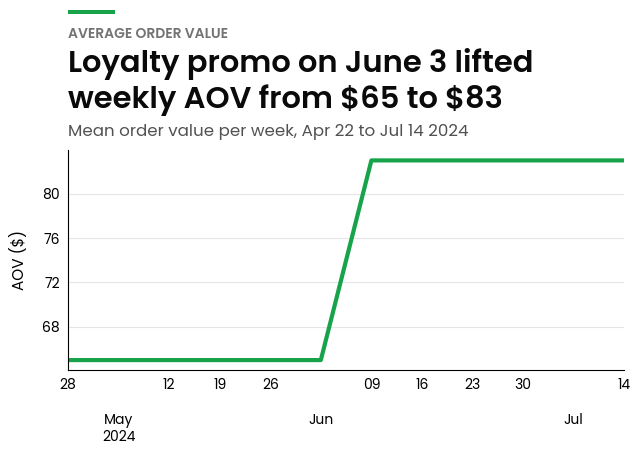

In [ ]:
ax = time.plot(
    transactions,
    value_col="order_value",
    period="W",
    agg_func="mean",
    eyebrow="Average order value",
    title="Loyalty promo on June 3 lifted weekly AOV from \\$65 to \\$83",
    subtitle="Mean order value per week, Apr 22 to Jul 14 2024",
    y_label="AOV ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Grouped by Category

Pass `group_col` to draw one line per category from a long-format DataFrame. Each group gets a distinct hue from the categorical palette so the lines stay distinguishable. Best with three to six groups; beyond that the colors start to blur and end-of-line labels (next example) read better than a legend.

---

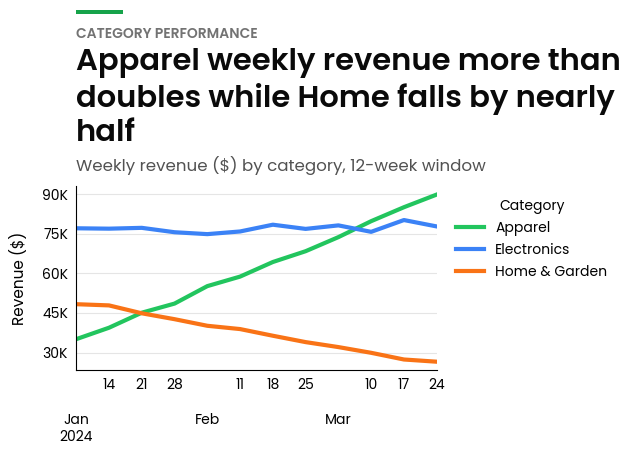

In [ ]:
ax = time.plot(
    category_sales,
    value_col="revenue",
    group_col="category",
    period="W",
    eyebrow="Category performance",
    title="Apparel weekly revenue more than doubles while Home falls by nearly half",
    subtitle="Weekly revenue ($) by category, 12-week window",
    y_label="Revenue ($)",
    legend_title="Category",
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis)
plt.show()

## End-of-Line Legend

Pass `legend_style="end_of_line"` to drop the boxed legend and place a colored series label at the right end of each line instead. The label sits next to the data it describes, so the eye doesn't have to bounce between a swatch and the line. Reads cleaner with three to five series; more than that and the labels start crowding each other (the function bumps overlapping labels apart vertically and draws a leader back to the line end).

---

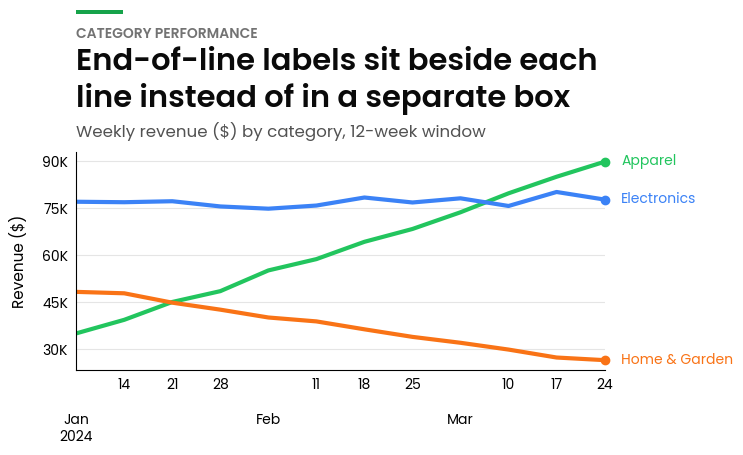

In [ ]:
ax = time.plot(
    category_sales,
    value_col="revenue",
    group_col="category",
    period="W",
    legend_style="end_of_line",
    eyebrow="Category performance",
    title="End-of-line labels sit beside each line instead of in a separate box",
    subtitle="Weekly revenue ($) by category, 12-week window",
    y_label="Revenue ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Source Attribution

`source_text` adds a small attribution line below the plot, useful for export-ready images that will live outside the notebook. Pair it with `eyebrow`, `subtitle`, and a clear `y_label` for a chart that reads as a finished artifact.

---

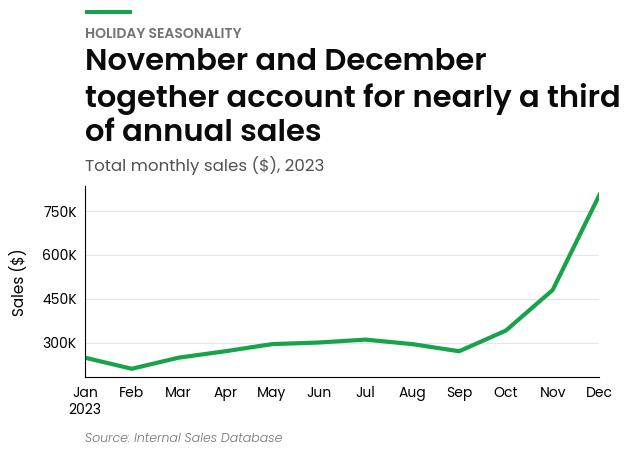

In [ ]:
ax = time.plot(
    annual_sales,
    value_col="sales",
    period="M",
    eyebrow="Holiday seasonality",
    title="November and December together account for nearly a third of annual sales",
    subtitle="Total monthly sales ($), 2023",
    y_label="Sales ($)",
    source_text="Source: Internal Sales Database",
)
set_axis_shorthand(ax.yaxis)
plt.show()